# Setup

## Import modules

In [12]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image
import torch
from datetime import datetime

# Import pipeline modules
from scoring import score_image
from selection import select
from metrics import MetricsTracker
from generation.UnconditionalGenerator import UnconditionalGenerator
from generation.LatentSurvivalGenerator import LatentSurvivalGenerator
from utils import save_image, set_seed
import shutil

# Config
OUTPUT_DIR = Path("outputs")

# Experiment parameters
NUM_PROMPTS = 1
NUM_TRIALS = 1
ROUNDS = 4        # r
BATCH_SIZE = 4    # B
SEED = 42

# Chosen strategies
SELECTION_STRATEGY = "argmax"

# Baseline scoring rubric (example)
# CLIP_RUBRIC = {"type": "clip", "text": "A photorealistic portrait of a dog", "weight": 1.0}
# BRIGHTNESS_RUBRIC = {"type": "brightness", "weight": 1.0}

set_seed(SEED)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load diffusion model

In [2]:
from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
torch.cuda.empty_cache()
pipe.to("cuda")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "stabilityai/sdxl-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerAncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

## Load dataset

In [3]:
# Load dev and test datasets 
dev_dataset = pd.read_csv("data/dev_dataset.csv")
test_dataset = pd.read_csv("data/test_dataset.csv")

# Run simulation

In [ ]:
START_IDX = 0
DATASET = dev_dataset[START_IDX : START_IDX + NUM_PROMPTS]

metrics = MetricsTracker()
# policy = LatentSurvivalGenerator(pipe, alpha=0.1, gamma=1.0)
policy = UnconditionalGenerator(pipe)

# based on date and time
RUN_DIR = OUTPUT_DIR / datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RUN_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR = RUN_DIR / "images"
METRICS_CSV = RUN_DIR / "metrics.csv"

for trial in range(NUM_TRIALS):
    print("=" * 100)
    print(f"BEGINNING TRIAL {trial}")
    print("=" * 100)

    trial_id = f"trial{trial}"

    for item_idx, item in enumerate(tqdm(DATASET.to_dict(orient="records"), desc="prompts")):
        prompt_id = item["prompt_id"]
        prompt = item["prompt"]

        # Compile rubric
        rubric = {}
        for key, value in item.items():
            if key.startswith("rubric_"):
                rubric[key.replace("rubric_", "")] = value

        # Initialize policy
        policy.initialize(prompt=prompt, batch_size=BATCH_SIZE)

        print(f"\nItem {item_idx}:")
        print(f"\tprompt_id={prompt_id}")
        print(f'\tprompt="{prompt}"')
        print(f"\trubric={rubric}")
        print()

        prompt_outdir = IMAGES_DIR / prompt_id / trial_id

        for round in range(ROUNDS):
            first_round = round == 0

            print(f"\tRound {round}")
            round_outdir = prompt_outdir / f"round{round}"
            round_outdir.mkdir(parents=True, exist_ok=True)

            # Score and record metrics for each image in the batch
            user_scores = []

            # If not the first round, include the previous winner as the first image in the batch
            if not first_round:
                image_path = round_outdir / f"image{0}.png"
                previous_winner = metrics.clone_previous_winner(prompt_id, trial_id, round, image_path)  # the current round  # the new image path

                user_scores.append(previous_winner["user_score"])
                # clone the previous winner image to the new destination
                shutil.copy(previous_winner["image_path"], image_path)

            # Generate the necessary number of images using our method
            new_images: list[Image.Image] = policy.generate(
                sampling_parameters={
                    "num_inference_steps": 1,
                    "guidance_scale": 0.0, # very important to set to 0.0 for SDXL-Turbo
                    # "width": 512,
                    # "height": 512,
                    # "generator": torch.Generator(device="cuda").manual_seed(SEED), # this leads to different trials having the same images
                }
            )

            for image_idx, image in zip(range(0 if first_round else 1, BATCH_SIZE), new_images):
                image_path = round_outdir / f"image{image_idx}.png"

                user_score = score_image(image, rubric)
                user_scores.append(user_score)

                metrics.log(
                    prompt_id,
                    trial_id,
                    round,
                    image_idx,
                    image_path,
                    user_score,
                    image,
                    extra_info={
                        "prompt": prompt,
                    },
                )
                save_image(image, image_path)

            # Select favorite (index)
            chosen_image_idx = select(user_scores, strategy=SELECTION_STRATEGY)
            metrics.mark_chosen(
                prompt_id,
                trial_id,
                round,
                chosen_image_idx,
            )

            # Update policy
            policy.update(winner_index=chosen_image_idx)

            print(f"\t\tImages saved to {round_outdir}")
            print(f"\t\tScores: {user_scores}")
            print(f"\t\tChosen index (using {SELECTION_STRATEGY}): {chosen_image_idx}")

        # Repeatedly save metrics per item, for safety
        metrics.save(str(METRICS_CSV))  # autoprints

BEGINNING TRIAL 0


prompts:   0%|          | 0/1 [00:00<?, ?it/s]


Item 0:
	prompt_id=001369-0084
	prompt="greek or roman sculpture in marble of a philosopher holding a skull, in a museum background, hyperrealistic photograph in the style of bernini, golden hour"
	rubric={'type': 'ImageReward', 'prompt': 'greek or roman sculpture in marble of a philosopher holding a skull, in a museum background, hyperrealistic photograph in the style of bernini, golden hour'}

	Round 0


  0%|          | 0/2 [00:00<?, ?it/s]

		Images saved to outputs/2025-11-25_04-32-16/images/001369-0084/trial0/round0
		Scores: [0.8935779929161072, 0.2465571016073227, 0.3160289525985718, 0.48901835083961487]
		Chosen index (using argmax): 0
	Round 1


...

		Images saved to outputs/2025-11-25_04-32-16/images/001369-0084/trial0/round1
		Scores: [0.8935779929161072, 0.5706443190574646, -0.07158120721578598, -0.3202296197414398]
		Chosen index (using argmax): 0
	Round 2


  0%|          | 0/2 [00:00<?, ?it/s]

		Images saved to outputs/2025-11-25_04-32-16/images/001369-0084/trial0/round2
		Scores: [0.8935779929161072, 1.4653522968292236, 0.8618528842926025, 0.7494973540306091]
		Chosen index (using argmax): 1
	Round 3


  0%|          | 0/2 [00:00<?, ?it/s]

		Images saved to outputs/2025-11-25_04-32-16/images/001369-0084/trial0/round3
		Scores: [1.4653522968292236, 0.5838645100593567, 0.28798988461494446, -0.7780634760856628]
		Chosen index (using argmax): 0
[MetricsTracker] Saved 16 records to outputs/2025-11-25_04-32-16/metrics.csv


In [ ]:
metrics.to_dataframe()

In [ ]:
new_latents.shape

In [ ]:
# Generate with these new latents
pipe(
    prompt="A photo of an astronaut riding a horse on mars",
    latents=new_latents,
    num_images_per_prompt=1,
    width=512,
    height=512,
    num_inference_steps=20,
    guidance_scale=7.5,
).images[0]

In [ ]:
# get the second prompt from our dev dataset
dev_dataset.iloc[5]["prompt"]

  0%|          | 0/1 [00:00<?, ?it/s]

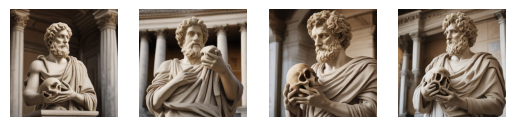

In [11]:
images = pipe(
    prompt="greek or roman sculpture in marble of a philosopher holding a skull, in a museum background, hyperrealistic photograph in the style of bernini, golden hour",
    num_images_per_prompt=4,
    num_inference_steps=1,
    guidance_scale=0.0,
    width=512,
    height=512,
).images

# display the images
for i, image in enumerate(images):
    plt.subplot(1, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
plt.show()